# Q3. FEATURE ENGINEERING & REGRESSION TIMELINE

Task 1 - Data Feature Engineering

In [41]:
import pandas as pd
df = pd.read_csv('q3_retail_promotions.csv')

#Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

#Extract Features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

#Month end flag
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x:1
                                          if x >=25 else 0)
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Task 2 - Temporal Train Test Split

In [42]:
df=df.sort_values(by=['transaction_date'])
index= int(len(df)*0.8)
train = df.iloc[:index]
test = df.iloc[index:]
X_train = train.drop('items_sold', axis=1)
y_train = train['items_sold']
X_test = test.drop('items_sold', axis=1)
y_test = test['items_sold']

X_train=X_train.drop('transaction_date', axis=1)
X_test=X_test.drop('transaction_date', axis=1)

print(X_train.shape, X_test.shape)

(960, 11) (240, 11)


**Note:**

Temporal Split

A random split is not suitable for time based data because it mixes past and future data, which can cause data leakage.

By splitting based on time, we train the data on past data and test it on future data, which gives more realistic results.

Task 3 - Preprocessing Pipeline

In [43]:
from re import X
cols=['promotion_type','location_type','store_size']
n_col=[col for col in X_train.columns if col not in cols]
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), n_col),
        ('cat', OneHotEncoder(drop='first'), cols)])
pl = Pipeline(steps=[('preprocessor', preprocessor)])
X_train_pp = pl.fit_transform(X_train)
X_test_pp = pl.transform(X_test)
print(X_train_pp.shape, X_test_pp.shape)

(960, 16) (240, 16)


Task 4 - Model Training & Evaluation

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
#Linear Regresion Pipeline
lrp = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', LinearRegression())])
#Random Forest Pipeline
rfp = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', RandomForestRegressor(random_state=42))])
#Train Models
lrp.fit(X_train, y_train)
rfp.fit(X_train, y_train)
#Prediction
lr_pred = lrp.predict(X_test)
rf_pred = rfp.predict(X_test)

In [45]:
#Metrics (RMSE  & MAE)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
# Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)

# Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Linear Regression - RMSE: ",lr_rmse)
print("Linear Regression - MAE: ",lr_mae)
print()
print("Random Forest - RMSE: ",rf_rmse)
print("Random Forest - MAE: ",rf_mae)

Linear Regression - RMSE:  27.12145116489062
Linear Regression - MAE:  21.052926674588395

Random Forest - RMSE:  31.658897860633115
Random Forest - MAE:  24.904708333333335


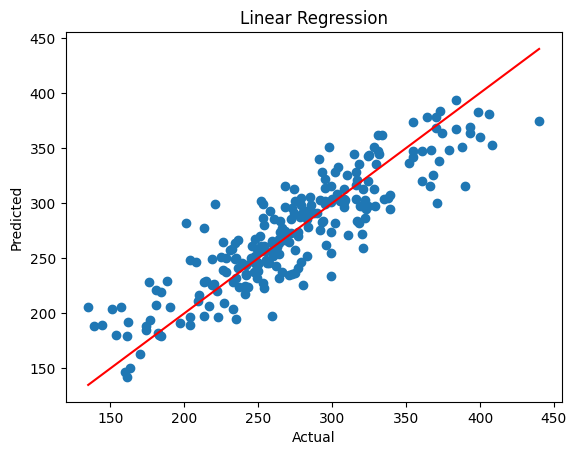

In [46]:
import matplotlib.pyplot as plt

plt.scatter(y_test, lr_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression')
plt.show()

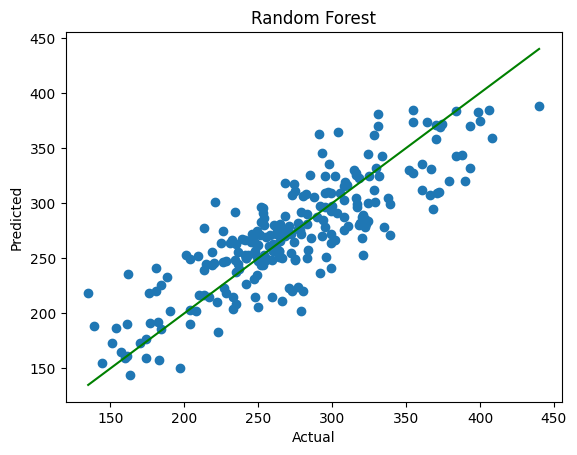

In [47]:
plt.scatter(y_test, rf_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='green')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest')
plt.show()


In [48]:
# Feature Importance
f_name = lrp.named_steps['preprocessor'].get_feature_names_out()
importances = rfp.named_steps['model'].feature_importances_
f_imp_df = pd.DataFrame({'Feature': f_name, 'Importance': importances})
f_imp_df = f_imp_df.sort_values(by='Importance', ascending=False)
f_imp_df.head()

,Feature,Importance
15,cat__store_size_small,0.183953
2,num__is_festival,0.174490
13,cat__location_type_urban,0.140494
6,num__day_of_week,0.087179
1,num__is_weekend,0.066870
